## Imports and setup

In [1]:
import territorial_automaton as ta
import visualization as vis
import topology as topo
import storage
import helpers

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import os
from tqdm.notebook import tqdm

if not os.path.exists('figures/th_k_phase'):
    os.makedirs('figures/th_k_phase')

In [ ]:
T_LOW = 1.0
L = 32
SEED = 8
GRID, POS = topo.grid(N=L, periodic=True)

STORE = storage.Store.create(
    'th_k_phase_extended_T_low.h5',
    "Phase diagram on the extended theta-kappa plane below the Ising critical temperature",
    GRID, pos=POS,
    topology_info={'type': 'grid', 'N': L, 'periodic': True},
    base_params={'T': T_LOW, 'h': 0.0, 'seed': SEED},
)
# STORE = storage.Store.open('th_k_phase_T_low.h5')

## Run the model

In [3]:
theta_values = np.linspace(0.0, 1.0, 30)
kappa_values = np.linspace(-1.0, 1.0, 60)
warmup = 2000
experiment = 5000
n_runs = 25


In [4]:
models = []
for i, theta in enumerate(theta_values):
    row = []
    for j, kappa in enumerate(kappa_values):
        params = ta.TA_Params(adj_matrix=GRID, T=T_LOW, h=0.0, theta=theta, kappa=kappa, seed=SEED)
        model = ta.TerritorialAutomaton(params)
        row.append(model)
    models.append(row)

results = helpers.run_models_2d(models, warmup, experiment, n_runs, SEED, store=STORE)

Resuming: 34103/45000 runs loaded from store, running 10897 remaining


  0%|          | 0/10897 [00:00<?, ?it/s]

In [5]:
mean_orders = np.array([[results[i][j].mean_abs_order for j in range(len(kappa_values))]
                         for i in range(len(theta_values))])
mean_factionless = np.array([[results[i][j].mean_factionless_fraction for j in range(len(kappa_values))]
                              for i in range(len(theta_values))])
mean_order_variance = np.array([[results[i][j].order_variance for j in range(len(kappa_values))]
                                 for i in range(len(theta_values))])

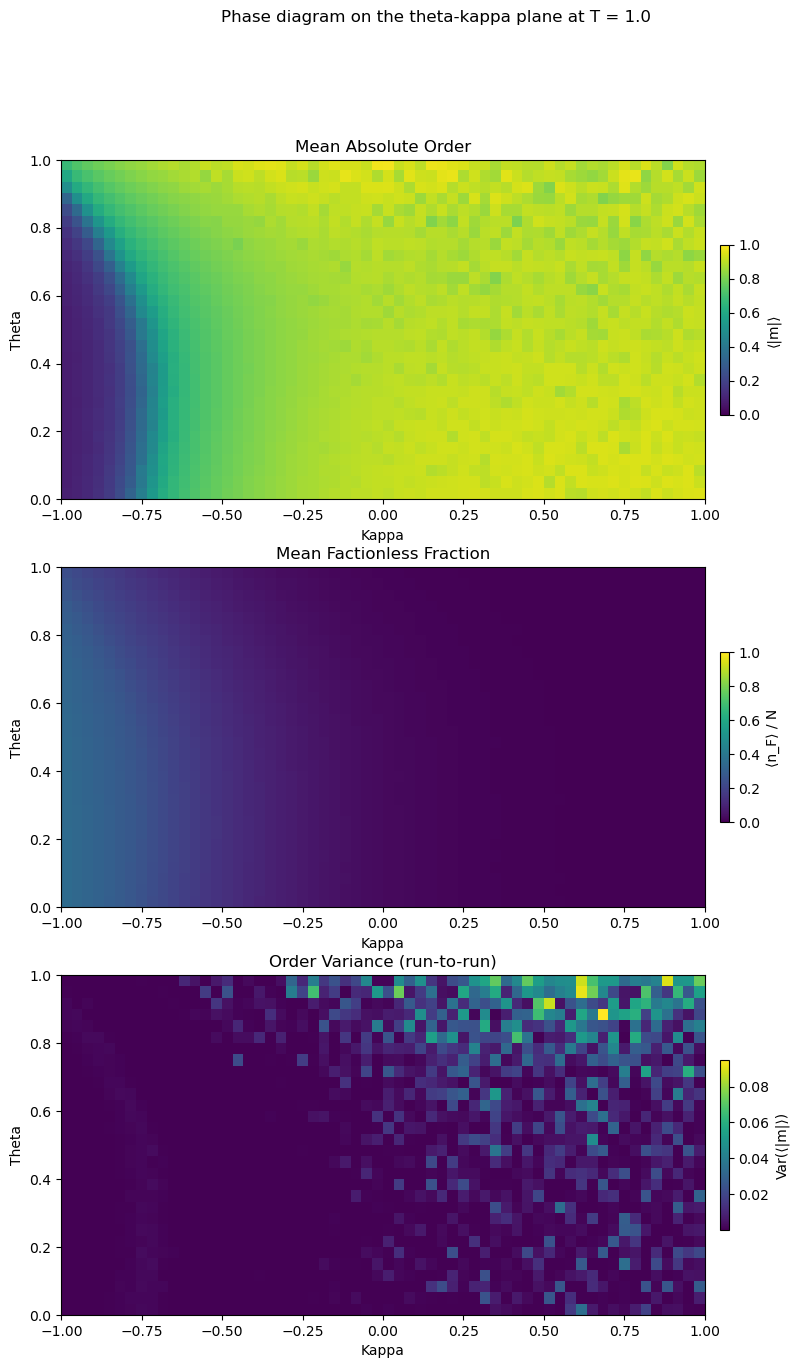

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(10, 15))
plt.suptitle("Phase diagram on the extended theta-kappa plane at T = 1.0")

im0 = axs[0].imshow(
    mean_orders,
    extent=(kappa_values[0], kappa_values[-1], theta_values[0], theta_values[-1]),
    origin='lower', aspect='auto', cmap='viridis', vmin=0, vmax=1,
)
fig.colorbar(im0, ax=axs[0], label='⟨|m|⟩', shrink=0.5, pad=0.02)
axs[0].set_title("Mean Absolute Order")
axs[0].set_xlabel("Kappa")
axs[0].set_ylabel("Theta")

im1 = axs[1].imshow(
    mean_factionless,
    extent=(kappa_values[0], kappa_values[-1], theta_values[0], theta_values[-1]),
    origin='lower', aspect='auto', cmap='viridis', vmin=0, vmax=1,
)
fig.colorbar(im1, ax=axs[1], label='⟨n_F⟩ / N', shrink=0.5, pad=0.02)
axs[1].set_title("Mean Factionless Fraction")
axs[1].set_xlabel("Kappa")
axs[1].set_ylabel("Theta")

im2 = axs[2].imshow(
    mean_order_variance,
    extent=(kappa_values[0], kappa_values[-1], theta_values[0], theta_values[-1]),
    origin='lower', aspect='auto', cmap='viridis',
)
fig.colorbar(im2, ax=axs[2], label='Var(⟨|m|⟩)', shrink=0.5, pad=0.02)
axs[2].set_title("Order Variance (run-to-run)")
axs[2].set_xlabel("Kappa")
axs[2].set_ylabel("Theta")

plt.savefig('figures/th_k_phase/phase_diagram_extended_t_low.png')
plt.show()